# Epoch AI Training Data Analysis
#### Kara Taylor

# Project Overview

**Fact:** AI training inputs such as compute and parameters have increased overtime.

**Question:** Are there differences in the rate of change of these training inputs between data categories such as:<br>
* Organizations (i.e. Open AI vs Google)<br>
* Organization Category (i.e. Academia vs. Industry)<br>
* Country (i.e. US vs Others)<br>
* Domain (i.e. Language vs. Visual)<br>

Data Source Overview: https://epoch.ai/data/ai-models?view=graph&tab=notable<br>
Complete Documentation: https://epoch.ai/data/ai-models-documentation<br>
Download Data File: https://epoch.ai/data/notable_ai_models.csv<br>
Note: Data File changes almost daily, file used in analysis as of Oct 1, 2026

# Initial Data Review

#### Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('notable_ai_models.csv')

In [3]:
pd.set_option('display.max_columns', None)    #to see all columns
pd.options.display.float_format = '{:,.2f}'.format     #to remove scientific notion, display floats with , and 2 decimals

In [4]:
df.sample(5)

,Model,Organization,Publication date,Domain,Task,Parameters,Parameters notes,Training compute (FLOP),Training compute notes,Training dataset,Training dataset size (total),Dataset size notes,Confidence,Link,Reference,Citations,Authors,Abstract,Organization categorization,Country (of organization),Notability criteria,Notability criteria notes,Epochs,Training time (hours),Training time notes,Training hardware,Hardware quantity,Hardware utilization (MFU),Training compute cost (2023 USD),Compute cost notes,Training power draw (W),Base model,Finetune compute (FLOP),Finetune compute notes,Batch size,Batch size notes,Model accessibility,Training code accessibility,Inference code accessibility,Accessibility notes,Numerical format,Frontier model,Hardware acquisition cost,Hardware utilization (HFU),Training compute cost (cloud),Training compute cost (upfront),Open model weights?
161,Qwen3-235B-A22B,Alibaba,2025-04-29,Language,"Language modeling/generation,Question answerin...","235,000,000,000.00",235 billion total parameters and 22 billion ac...,"4,752,000,000,000,000,100,663,296.00",6 FLOP / parameter / token * 22*10^9 active pa...,Unspecified unreleased,36000000000000,36T,Likely,https://qwenlm.github.io/blog/qwen3/,"Qwen3: Think Deeper, Act Faster",NaN,NaN,"Today, we are excited to announce the release ...",Industry,China,Discretionary,Major Alibaba release,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not listed,Open weights (unrestricted),Unreleased,NaN,Apache 2.0\n\nhttps://huggingface.co/Qwen/Qwen...,NaN,NaN,NaN,NaN,NaN,NaN,Yes
190,Eurus-2-7B-PRIME,"Tsinghua University,University of Illinois Urb...",2025-01-02,"Mathematics,Language","Mathematical reasoning,Code generation","7,000,000,000.00",NaN,"401,915,904,000,000,000,000.00",Hardware-based estimate from the RL training: ...,Eurus-2-RL-Data,830000,"""We finally obtain 230K SFT data and the avera...",Speculative,https://arxiv.org/abs/2502.01456,Process Reinforcement through Implicit Rewards,333.00,"Ganqu Cui, Lifan Yuan, Zefan Wang, Hanbin Wang...",Dense process rewards have proven a more effec...,"Academia,Academia,Academia,Academia,Academia","China,United States of America,China,China,Chi...",SOTA improvement,"Table 2\n\n""Eurus-2-7B-PRIME excels at competi...",3.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Qwen2.5-Math-7B-Base,"1,342,740,000,000,000,000.00",For SFT: 6 * 7e9 parameters * 319700000 tokens...,NaN,NaN,Open weights (unrestricted),Open source,Open source,Apache 2.0\nhttps://huggingface.co/PRIME-RL/Eu...,BF16,NaN,NaN,NaN,NaN,NaN,Yes
953,LCNP MNIST,NaN,2009-11-22,Vision,Object recognition,"11,616,256.00",Locally connected: 128*128*4*4*4*5 + 64*64*8*4...,"4,181,852,160,000,000.00",2*11616256*3*60000*1000=4181852160000000,MNIST,50000,NaN,Confident,https://ieeexplore.ieee.org/document/5357786,Large-scale object recognition with CUDA-accel...,NaN,"Rafael Uetz, Sven Behnke",Robust recognition of arbitrary object classes...,NaN,NaN,Historical significance,NaN,"1,000.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN
1063,Heuristic Reinforcement Learning,Purdue University,1965-10-01,Robotics,System control,NaN,NaN,"1,080,000.00",Figure 10 shows their largest system is traine...,NaN,NaN,NaN,Speculative,https://ieeexplore.ieee.org/document/1098193,A heuristic approach to reinforcement learning...,NaN,"M. Waltz, K. Fu",This paper describes a learning control system...,Academia,United States of America,"Historical significance,Highly cited",NaN,NaN,3.00,Figure 10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42,Claude Opus 4.8,Anthropic,2026-05-28,Language,Language modeling/generation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Confident,https://www.anthropic.com/news/claude-opus-4-8,Introducing Claude Opus 4.8,NaN,NaN,NaN,Industry,United States of America,Significant use,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,API access,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No


#### Initial Observations

Data loaded via csv file.  Several issues noted on initial review: 
* Column Names include capital letters, spaces, and parentheses
* Several null values noted 
* Multiple value entries noted

Columns needed to answer the question:<br>
* Model: Key or unique identifier for all rows<br>
* Organization: Category of interest<br>
* Publication date: To look at change over time<br>
* Domain: Category of interest<br>
* Parameters: Numeric measure<br>
* Training compute (FLOP): Numeric measure<br>
* Organization categorization: Category of interest<br>
* Country (of organization): Category of interest<br>

Additional columns that maybe interesting: Notability criteria, Frontier model

# Data Integrity Audit

#### Shape, Columns, Data Types

First, fix column names using to_snake to convert column name to all lower case with snake case.

In [5]:
#apply to_snake to the column names 
def to_snake(columns):
    'Lowercase, turn anything that is not a letter or digit into _, trim stray underscores.'
    return (pd.Index(columns)
            .str.strip()
            .str.lower()
            .str.replace(r"[^0-9a-z]+", "_", regex=True)
            .str.strip("_"))

original_names = df.columns
df.columns = to_snake(df.columns)

pd.DataFrame({"before": original_names, "after": df.columns})

,before,after
0,Model,model
1,Organization,organization
2,Publication date,publication_date
3,Domain,domain
4,Task,task
5,Parameters,parameters
6,Parameters notes,parameters_notes
7,Training compute (FLOP),training_compute_flop
8,Training compute notes,training_compute_notes
9,Training dataset,training_dataset


Updated "After" column names will minimize errors 

In [6]:
df.shape

(1078, 47)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1078 entries, 0 to 1077
Data columns (total 47 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   model                           1078 non-null   str    
 1   organization                    1060 non-null   str    
 2   publication_date                1078 non-null   str    
 3   domain                          1075 non-null   str    
 4   task                            1073 non-null   str    
 5   parameters                      725 non-null    float64
 6   parameters_notes                694 non-null    str    
 7   training_compute_flop           540 non-null    float64
 8   training_compute_notes          633 non-null    str    
 9   training_dataset                630 non-null    str    
 10  training_dataset_size_total     668 non-null    str    
 11  dataset_size_notes              565 non-null    str    
 12  confidence                      1003 non-null

Data has 1078 rows and 47 columns.<br>
Several columns have low numbers of non-null values.<br>
Data Types are not optimal.

Data Type Observations:
* publication_date: str to date as it is a date and will be used in this analysis
* training_dataset_size_total: str to numeric as is a number (not expected to use, but should fix if able)*
* frontier_model: str to bool for conditional logic test and may be used in analysis
* several others maybe best as categories, but not recommended to change unless EDA necessitates
  
*Audit first to see if changing to numeric would cause issues

In [8]:
#audit training_dataset_size_total as is a column that should be numeric
def coerce_report(series):
    """Convert to numbers, and print every value that was text and became NaN."""
    converted = pd.to_numeric(series, errors="coerce")
    lost = series[converted.isna() & series.notna()]
    print(f"{len(lost)} values were not numbers and became NaN:")
    print(lost.value_counts().to_string())
    return converted

df["training_dataset_size_total_num"] = coerce_report(df.training_dataset_size_total)

3 values were not numbers and became NaN:
training_dataset_size_total
2260275840,2290000001     1
327978752,192851506176    1
14180000,14180000         1


training_dataset_size_total Observation: There are 3 training_dataset_size_total entries with two numbers in them. Running pd.to_numeric with coerce errors would turn them to NaN.

training_dataset_size_total Handling: no action, I do not plan to use this column and so will leave it alone for now.  If I choose to use it later analysis I will have to handle the duplicate entries and change to numeric before use.  

#### Missing Values, Duplicates, Repeats, Validity Check, Outliers
More indepth audit of the 10 columns considered for analysis

##### Model

In [9]:
df.model.value_counts(dropna=False)

model
Gemini 4 Argon                        1
GPT-6.1 Sol                           1
Claude Sonnet 5.5                     1
GPT-6 Sol                             1
GPT-6 Luna                            1
                                     ..
Sequence-based pattern recognition    1
Self Organizing System                1
Genetic algorithm                     1
SNARC                                 1
Theseus                               1
Name: count, Length: 1078, dtype: int64

In [10]:
df.model.describe()

count               1078
unique              1078
top       Gemini 4 Argon
freq                   1
Name: model, dtype: object

In [11]:
df.model.isna().sum()

np.int64(0)

Model Observation:  This is a unique identity code, no nulls, no repeats, no duplicates noted

Model Handling:  No action needed

##### Publication Date

In [12]:
df.publication_date.value_counts(dropna=False)

publication_date
2026-04-23    4
2012-06-03    4
2009-08-01    4
1994-12-02    4
2026-09-22    3
             ..
1959-02-01    1
1957-01-01    1
1954-07-02    1
1952-01-08    1
1950-07-02    1
Name: count, Length: 874, dtype: int64

In [13]:
df.publication_date.describe()

count           1078
unique           874
top       2026-04-23
freq               4
Name: publication_date, dtype: object

In [14]:
df.publication_date.isna().sum()

np.int64(0)

Publication Date Observation:  This is a unique identity code, no nulls, no repeats, no duplicates noted

Publication Date Handling:  Change data type to date

##### Organization, Organization Categorization, Country of Organization

Organization

In [15]:
df.organization.value_counts(dropna=False)

organization
OpenAI                                                77
Google                                                54
Google DeepMind                                       42
Alibaba                                               34
Meta AI                                               31
                                                      ..
Cornell Aeronautical Laboratory                        1
Sandia Corporation                                     1
Cornell Aeronautical Laboratory,Cornell University     1
Institute for Advanced Study                           1
Harvard University                                     1
Name: count, Length: 444, dtype: int64

In [16]:
df.organization.describe()

count       1060
unique       443
top       OpenAI
freq          77
Name: organization, dtype: object

In [17]:
df.organization.isna().sum()

np.int64(18)

Organization Observation: Several lines have multiple organizations; no repeated values noted; minimal nulls. No clear top categories.

Organization Handling:  No action needed here.  Further review needed to determine how to categorize.  

Organization Categorization

In [18]:
df.organization_categorization.value_counts(dropna=False)

organization_categorization
Industry                                                                                                                                                                                                                                                                                                                       581
Academia                                                                                                                                                                                                                                                                                                                       173
Industry,Academia                                                                                                                                                                                                                                                                                                               57
Aca

In [19]:
df.organization_categorization.describe()

count         1058
unique          48
top       Industry
freq           581
Name: organization_categorization, dtype: object

In [20]:
df.organization_categorization.isna().sum()

np.int64(20)

Organization Categorization Observation: Several lines have multiple categories and repeated values noted; minimal nulls.  Most are Industry or Academia.

Organization Categorization handling: I will use a 'Split, Trim, De-duplicate, Sort' function to handle repeats and then create a higher-level categorization to align any multi-organization_category to a "collaboration" category.   

Note: I originally thought to keep Government and Research collective separate, but they are such small counts I'll roll them as "Other" and combine with Collaboration

Country of Organization

In [21]:
df.country_of_organization.value_counts(dropna=False)

country_of_organization
United States of America                                    462
China                                                       123
United States of America,United States of America            79
United Kingdom                                               55
Canada                                                       28
                                                           ... 
France,Canada                                                 1
Spain                                                         1
United States of America,United States of America,Canada      1
Finland                                                       1
Croatia                                                       1
Name: count, Length: 150, dtype: int64

In [22]:
#how many have US and China
(df.country_of_organization.str.contains('United States of America', na=False) & df.country_of_organization.str.contains('China', na=False)).sum()

np.int64(30)

In [23]:
df.country_of_organization.describe()

count                         1059
unique                         149
top       United States of America
freq                           462
Name: country_of_organization, dtype: object

In [24]:
df.country_of_organization.isna().sum()

np.int64(19)

Country Observation: Several lines have multiple categories and repeated values noted; minimal nulls.  Most are US or China and a few with both US and China. 

Country handling: I will use a 'Split, Trim, De-duplicate, Sort' function to handle repeats and then create a higher-level categorization.  
* US: US & US + US + 'any other non-China country'
* China: China & China + 'any other non-US country'
* US + China
* Other

Note: I originally thought to keep US and US + Other separate as well as China and China + Other seperate, but it was too many categories so I combined.  

Note on Organization Columns:  Organization, Organization Category, and Country of Organization are all related. If multiple organizations are listed, there will be the same number of organization categories listed as well as same number of country of organizations listed.  In other words, for each organization, the input will not the organization categorizationa and country even if they are the same.  This is why we get multiple repeats.  

Does not change handling recommendation; however, once repeates are removed, the 1-to-1-to-1 alignment maybe lost with potential change to many-to-1 alignment.  I.e. Stanford, Google, and Georgia will still show separately, but the categorization will be reduced to Academia and Industry (losing exact match of orgniazation to category), and country will be reduced to just US.

In [25]:
# example where US is listed 3 times, for the 3 orgs.  
df.loc[[297], ['model', 'organization', 'organization_categorization', 'country_of_organization']]

,model,organization,organization_categorization,country_of_organization
297,W.A.L.T,"Stanford University,Google Research,Georgia In...","Academia,Industry,Academia","United States of America,United States of Amer..."


##### Domain

In [26]:
df.domain.value_counts(dropna=False)

domain
Language                      402
Vision                        201
Multimodal,Language,Vision     47
Games                          47
Image generation               43
                             ... 
Vision,Games                    1
Search                          1
Driving                         1
Robotics,Games                  1
Mathematics,Biology             1
Name: count, Length: 93, dtype: int64

In [27]:
df.domain.describe()

count         1075
unique          92
top       Language
freq           402
Name: domain, dtype: object

In [28]:
df.domain.isna().sum()

np.int64(3)

Domain Observation: Several lines have multiple domains; no repeated values noted; very few nulls.

Domain Handling: I will create a new column for higher-level categorization.  For example, several one-off categories such as mathematics, biology could be combined into an "other" category.   Note: I originally thought to keep audio separate but it was a relatively small count so will roll that into other as well.

##### Notable Criteria & Frontier Model

Notable Criteria

In [29]:
df.notability_criteria.value_counts()

notability_criteria
SOTA improvement                                                          471
Highly cited                                                              168
Discretionary                                                              88
Historical significance                                                    63
Highly cited,SOTA improvement                                              61
Training cost                                                              57
Significant use                                                            53
Historical significance,Highly cited                                       23
Highly cited,Historical significance                                       18
Historical significance,SOTA improvement                                    9
SOTA improvement,Significant use                                            8
SOTA improvement,Training cost                                              6
SOTA improvement,Highly cited               

In [30]:
df.notability_criteria.describe()

count                 1078
unique                  44
top       SOTA improvement
freq                   471
Name: notability_criteria, dtype: object

In [31]:
df.notability_criteria.isna().sum()

np.int64(0)

Notable Criteria Observations: Several lines have multiple reasons; no repeated values noted; no nulls. No clear top categories.  State of the Art (SOTA) and Highly cited are top reasons.

Organization Handling:  After further review, I don't think this column will be useful. No recommended changes for now.  

Frontier Model

In [32]:
df.frontier_model.value_counts(dropna=False)

frontier_model
NaN     954
True    124
Name: count, dtype: int64

In [33]:
df.frontier_model.describe()

count      124
unique       1
top       True
freq       124
Name: frontier_model, dtype: object

In [34]:
df.frontier_model.isna().sum()

np.int64(954)

Frontier Observation:  If it is a frontier model it is marked as true, otherwise it is NaN

Frontier Handling:  Change NaN to false, so it is clean for comparing frontier to non-frontier.  note: risk there could be a frontier model that missed marking true and will therefore be unintentionally marked False.

##### Training Compute (FLOP), Parameters

Training Compute (FLOP)

In [35]:
df.training_compute_flop.describe()

count                                     540.00
mean        5,692,137,661,063,411,055,722,496.00
std        53,099,566,194,313,101,465,092,096.00
min                                        40.00
25%                   711,684,500,000,000,000.00
50%             1,494,147,840,000,000,000,000.00
75%           296,000,000,000,000,016,777,216.00
max     1,000,099,999,999,999,966,202,298,368.00
Name: training_compute_flop, dtype: float64

In [36]:
df.training_compute_flop.isna().sum()

np.int64(538)

In [37]:
print("Percent of null compute:", round(df.training_compute_flop.isna().sum() / len(df) * 100, 2))

Percent of null compute: 49.91


In [38]:
df.training_compute_flop.skew()

np.float64(14.898469783081602)

<Axes: >

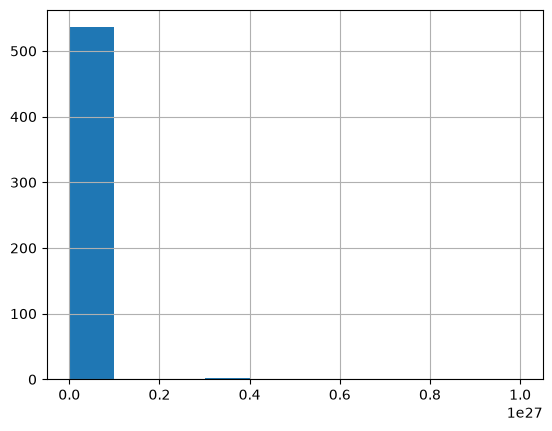

In [39]:
df.training_compute_flop.hist()

<Axes: >

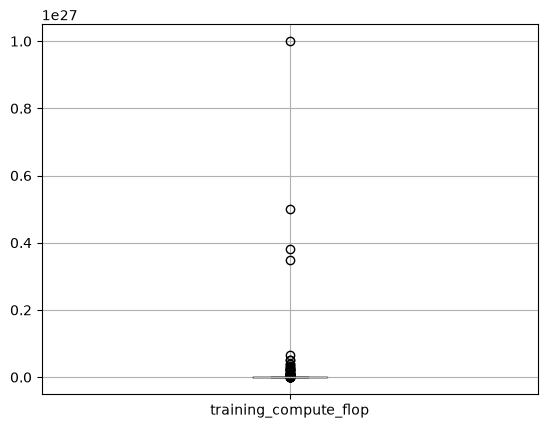

In [40]:
df.boxplot(column='training_compute_flop')

In [41]:
cutoff = df.training_compute_flop.quantile(0.99)
outliers = df[df.training_compute_flop >= cutoff]
outliers[['model', 'organization', 'training_compute_flop']]

,model,organization,training_compute_flop
14,GPT-6 Astra,OpenAI,"1,000,099,999,999,999,966,202,298,368.00"
132,GPT-5,OpenAI,"66,000,000,000,000,002,113,929,216.00"
148,Grok 4,xAI,"500,000,000,000,009,970,967,904,256.00"
166,Llama 4 Behemoth (preview),Meta AI,"51,840,000,000,000,096,368,328,704.00"
178,GPT-4.5,OpenAI,"380,000,000,000,000,021,541,945,344.00"
180,Grok 3,xAI,"350,000,000,000,000,059,626,225,664.00"


Training Compute (FLOP) Observations: Extreme range of compute with extreme skew

Training Compute (FLOP) Handling:  No clear option for missing data, will include analysis of trends in missing data.  Apparent outliers appear to be real data.  Will add a log10 column.  

Parameters

In [42]:
df.parameters.describe()

count                 725.00
mean      104,589,093,412.34
std       328,180,958,477.40
min                    16.00
25%            34,000,000.00
50%           550,000,000.00
75%        20,000,000,000.00
max     3,000,000,000,000.00
Name: parameters, dtype: float64

In [43]:
df.parameters.isna().sum()

np.int64(353)

In [44]:
print("Percent of null parameters:", round(df.parameters.isna().sum() / len(df) * 100, 2))

Percent of null parameters: 32.75


In [45]:
df.parameters.skew()

np.float64(5.250833880279601)

<Axes: >

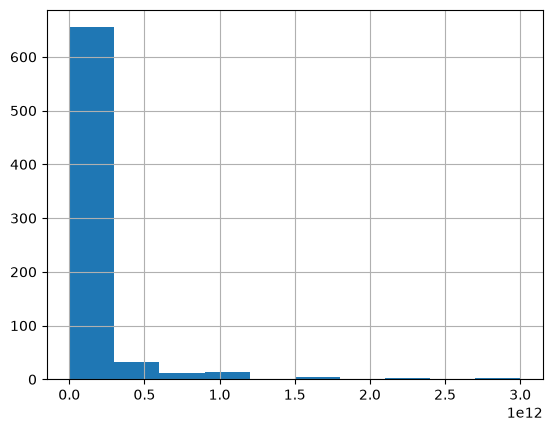

In [46]:
df.parameters.hist()

<Axes: >

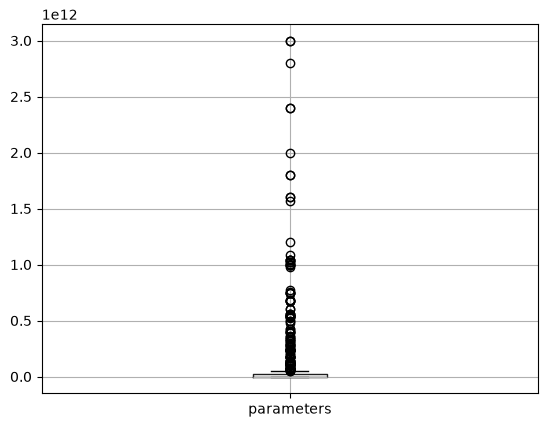

In [47]:
df.boxplot(column='parameters')

In [48]:
cutoff = df.parameters.quantile(0.99)
outliers = df[df.parameters >= cutoff]
outliers[['model', 'organization', 'parameters']]

,model,organization,parameters
23,Qwen3.8-2.4T-A95B,Alibaba,"2,400,000,000,000.00"
29,Qwen 3.8 Max,Alibaba,"2,400,000,000,000.00"
30,Kimi K3,Moonshot,"2,800,000,000,000.00"
148,Grok 4,xAI,"3,000,000,000,000.00"
166,Llama 4 Behemoth (preview),Meta AI,"2,000,000,000,000.00"
180,Grok 3,xAI,"3,000,000,000,000.00"
363,GPT-4 (Jun 2023),OpenAI,"1,800,000,000,000.00"
390,GPT-4 (Mar 2023),OpenAI,"1,800,000,000,000.00"


Parameters Obersvations: Extreme range of compue with extreme skew

Parameters Handling:  No clear option for missing data, will include analysis of trends in missing data.  Apparent outliers appears to be real data.  Will add a log10 column.  

# Cleaning & Remediation

#### Data Type

Change Data Type for publication_date and frontier_model

In [49]:
# publication_date: str to date
df.publication_date = pd.to_datetime(df.publication_date)

In [50]:
# frontier_model: str to bool and fill nan
df.frontier_model = df.frontier_model.fillna(False).astype(bool)# frontier_model: str to bool

#### Split, Trim, De-duplicate, Sort 

Clean multiple entries and duplicates for organization_categorization and country_of_organization<br>
Policy Handling:  1 model counted 1 time & create separate simplified higher-level category columns

In [51]:
#de-duplicate repeat and indicate multiple entries with a '+'
def clean_multi(value, sep=","):
    """Turn "b, a, b" into "a + b": split, trim, drop repeats, sort."""
    if pd.isna(value):
        return value
    parts = sorted({p.strip() for p in str(value).split(sep) if p.strip()})
    return " + ".join(parts)

df["org_cat_clean"] = df.organization_categorization.map(clean_multi)
df["country_clean"] = df.country_of_organization.map(clean_multi)

In [52]:
# cleaner version of organization categoriztion: still has multiple entries, but without the repeats
df.org_cat_clean.value_counts()

org_cat_clean
Industry                                                  614
Academia                                                  243
Academia + Industry                                       167
Academia + Research collective                              8
Research collective                                         5
Government + Industry                                       4
Government                                                  4
Academia + Industry + Research collective                   3
Industry + Research collective                              3
Academia + Government + Industry                            3
Academia + Government                                       3
Academia + Government + Industry + Research collective      1
Name: count, dtype: int64

In [53]:
# cleaner version of organization: still has multiple entries, but without the repeats
df.country_clean.value_counts()

country_clean
United States of America             563
China                                141
United Kingdom                        61
France + United States of America     34
Canada                                29
                                    ... 
Canada + Singapore                     1
Canada + France                        1
Spain                                  1
Finland                                1
Croatia                                1
Name: count, Length: 81, dtype: int64

#### Create Summary Category Columns

For organization, organization categorization, country, and domain I will create new columns for summary level categorizations. 

##### Organization

First determine which organizations are most relevant to this analysis.

In [54]:
#organizations with most notable models
df.organization.value_counts(dropna=False)

organization
OpenAI                                                77
Google                                                54
Google DeepMind                                       42
Alibaba                                               34
Meta AI                                               31
                                                      ..
Cornell Aeronautical Laboratory                        1
Sandia Corporation                                     1
Cornell Aeronautical Laboratory,Cornell University     1
Institute for Advanced Study                           1
Harvard University                                     1
Name: count, Length: 444, dtype: int64

In [55]:
#organizations with most training parameters
df.groupby("organization")["parameters"].max().sort_values(ascending=False)

organization
xAI                                                                                 3,000,000,000,000.00
Moonshot                                                                            2,800,000,000,000.00
Alibaba                                                                             2,400,000,000,000.00
Meta AI                                                                             2,000,000,000,000.00
OpenAI                                                                              1,800,000,000,000.00
                                                                                            ...         
University of Zagreb                                                                                 NaN
Université Paris-Est                                                                                 NaN
Visual Computing Institute,RWTH Aachen University                                                    NaN
Westlake University,Tsinghua University,To

In [56]:
#organizations with most training compute
df.groupby("organization")["training_compute_flop"].max().sort_values(ascending=False)

organization
OpenAI                                              1,000,099,999,999,999,966,202,298,368.00
xAI                                                   500,000,000,000,009,970,967,904,256.00
Meta AI                                                51,840,000,000,000,096,368,328,704.00
Google DeepMind                                        50,000,000,000,999,999,617,892,352.00
Cursor                                                 38,699,999,999,999,997,256,925,184.00
                                                                      ...                   
Visual Computing Institute,RWTH Aachen University                                        NaN
Writer                                                                                   NaN
Yahoo Research,AT&T                                                                      NaN
York University                                                                          NaN
Zhejiang University (ZJU)                                

Organization Categorization Grouping<br>
Considering these three inputs (most models, most compute, most parameters) I will creates a summary category for the following models:
* Open AI (Top compute, in top 5 for parameters, and most models)
* xAI (Top parameters, in top 5 for compute)
* Meta A (In top 5 for both compute and parameters)
* Alibaba (In top 5 for parameters and number of models)
* Google Combine with DeepMind (In top 5 for compute and number of models))
* Combine all others as "Other."

In [57]:
org_simplified = []

for value in df.organization:

    if pd.isna(value):
        org_simplified.append(value)

    elif 'OpenAI' in value:
        org_simplified.append('OpenAI')

    elif 'xAI' in value:
        org_simplified.append('xAI')

    elif 'Meta' in value:
        org_simplified.append('Meta AI')

    elif 'Alibaba' in value:
        org_simplified.append('Alibaba')

    elif 'Google' in value or 'DeepMind' in value:
        org_simplified.append('Google')

    else:
        org_simplified.append('Other')

df['org_simplified'] = org_simplified

In [58]:
df.org_simplified.value_counts()

org_simplified
Other      675
Google     216
OpenAI      79
Meta AI     44
Alibaba     37
xAI          9
Name: count, dtype: int64

In [59]:
#Visualize grouping
df.groupby(['org_simplified', 'organization']).size().reset_index(name='count')

,org_simplified,organization,count
0,Alibaba,Alibaba,34
1,Alibaba,"Alibaba,Huazhong University of Science and Tec...",1
2,Alibaba,"Alibaba,University of Waterloo,Vector Institute",1
3,Alibaba,"Tsinghua University,Alibaba DAMO Academy",1
4,Google,"ASAPP,Cornell University,Google,Princeton Univ...",1
...,...,...,...
438,Other,Zhejiang University (ZJU),1
439,Other,Zhuiyi Technology,1
440,Other,"deepset,Bayerische Staatsbibliothek Muenchen",1
441,Other,rinna,1


##### Organization Categorization

Organization Categorization Grouping<br>
* Industry & Academia stay single entry categories
* All multi-entry categories, government, and research collective will be labeled "Collaboration / Other"

In [60]:
org_cat_simplified = []

for value in df.org_cat_clean:

    if pd.isna(value):
        org_cat_simplified.append(value)

    elif value == 'Industry':
        org_cat_simplified.append('Industry')

    elif value == 'Academia':
        org_cat_simplified.append('Academia')

    else:
        org_cat_simplified.append('Collaboration / Other')

df['org_cat_simplified'] = org_cat_simplified

In [61]:
df.org_cat_simplified.value_counts()

org_cat_simplified
Industry                 614
Academia                 243
Collaboration / Other    201
Name: count, dtype: int64

In [62]:
#Visualize grouping
df.groupby(['org_cat_simplified', 'org_cat_clean']).size().reset_index(name='count')

,org_cat_simplified,org_cat_clean,count
0,Academia,Academia,243
1,Collaboration / Other,Academia + Government,3
2,Collaboration / Other,Academia + Government + Industry,3
3,Collaboration / Other,Academia + Government + Industry + Research co...,1
4,Collaboration / Other,Academia + Industry,167
5,Collaboration / Other,Academia + Industry + Research collective,3
6,Collaboration / Other,Academia + Research collective,8
7,Collaboration / Other,Government,4
8,Collaboration / Other,Government + Industry,4
9,Collaboration / Other,Industry + Research collective,3


##### Country of Organization

Country of Organization Grouping<br>
* Single Entry Categories stay seperate for US and China.
* Grouped categories for US + China, US + any other country, China + any other country.
* All other entries categorized as "Other"

In [63]:
country_simplified = []

for value in df.country_clean:

    if pd.isna(value):
        country_simplified.append(value)

    elif 'United States of America' in value and 'China' in value:
        country_simplified.append('US + China')

    elif 'United States of America' in value:
        country_simplified.append('US')

    elif 'China' in value:
        country_simplified.append('China')

    else:
        country_simplified.append('Other')

df['country_simplified'] = country_simplified

In [64]:
df.country_simplified.value_counts()

country_simplified
US            666
Other         204
China         159
US + China     30
Name: count, dtype: int64

In [65]:
#Visualize grouping
df.groupby(['country_simplified', 'country_clean']).size().reset_index(name='count')

,country_simplified,country_clean,count
0,China,Australia + China,1
1,China,Canada + China,1
2,China,China,141
3,China,China + Hong Kong,6
4,China,China + Hong Kong + Singapore,1
...,...,...,...
76,US + China,China + Germany + South Korea + United States ...,2
77,US + China,China + Hong Kong + United States of America,2
78,US + China,China + Singapore + United States of America,2
79,US + China,China + United Kingdom + United States of America,1


##### Domain

Domain Grouping<br>
* Language: Language<br>
* Vision & Media: Vision, Image generation, Video, 3D modeling<br>
* Multimodal: Multimodal<br>
* Other: Speech, Audio, Mathematics, Biology, Medicine, Robotics, Games, Earth science, Materials science, Cybersecurity, Search, Driving, Recommendation, Other

In [66]:
#Simplify 4 main categories Language (no change), Vision & Media (for Vision, Image gen, Video, 3D model), Audio (speech and Audio), Multimodal

# start with an empty list to collect the results (will turn it into a new column later)
domain_simplified = []

# go through every value in the domain column, one row at a time
for value in df.domain:
    
    if pd.isna(value):
        domain_simplified.append(value)
    
    elif 'Multimodal' in value:
        domain_simplified.append('Multimodal')
    
    elif 'Language' in value:
        domain_simplified.append('Language')
    
    elif 'Vision' in value or 'Image generation' in value or 'Video' in value or '3D modeling' in value:
        domain_simplified.append('Vision & Media')
      
    else:
        domain_simplified.append('Other')

# now assign the completed list as a new column
df['domain_simplified'] = domain_simplified

In [67]:
df.domain_simplified.value_counts()

domain_simplified
Language          435
Vision & Media    290
Other             213
Multimodal        137
Name: count, dtype: int64

In [68]:
#Visualize grouping
df.groupby(['domain_simplified', 'domain']).size().reset_index(name='count')

,domain_simplified,domain,count
0,Language,"Biology,Language",2
1,Language,"Biology,Vision,Language,Medicine",1
2,Language,"Cybersecurity,Language",2
3,Language,Language,402
4,Language,"Language,Biology",1
...,...,...,...
87,Vision & Media,Vision,201
88,Vision & Media,"Vision,Games",1
89,Vision & Media,"Vision,Image generation",8
90,Vision & Media,"Vision,Medicine",1


#### Create Log10 Numerical Columns

##### Training Compute (FLOP)

In [69]:
#create a log10 of training compute column
df['log10_compute'] = np.log10(df['training_compute_flop'])    

In [70]:
df.log10_compute.describe()

count   540.00
mean     20.13
std       4.35
min       1.60
25%      17.85
50%      21.17
75%      23.47
max      27.00
Name: log10_compute, dtype: float64

In [71]:
df.log10_compute.skew()

np.float64(-1.2347729019382103)

<Axes: >

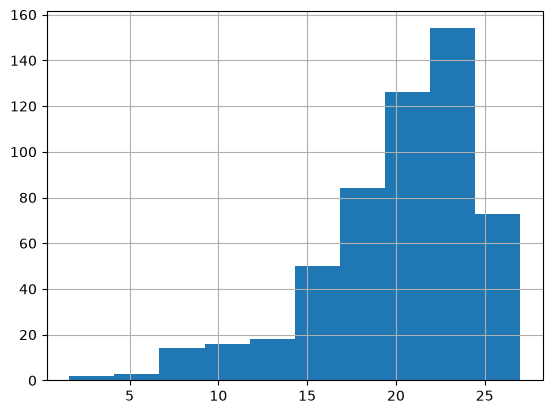

In [72]:
df.log10_compute.hist()

##### Parameter

In [73]:
#create a log10 of training parameters for not null and >0
df['log10_parameters'] = np.where(df['parameters'] > 0, np.log10(df['parameters']), np.nan)    

In [74]:
df.log10_parameters.describe()

count   725.00
mean      8.63
std       2.29
min       1.20
25%       7.53
50%       8.74
75%      10.30
max      12.48
Name: log10_parameters, dtype: float64

In [75]:
df.log10_parameters.skew()

np.float64(-0.7348285878560817)

<Axes: >

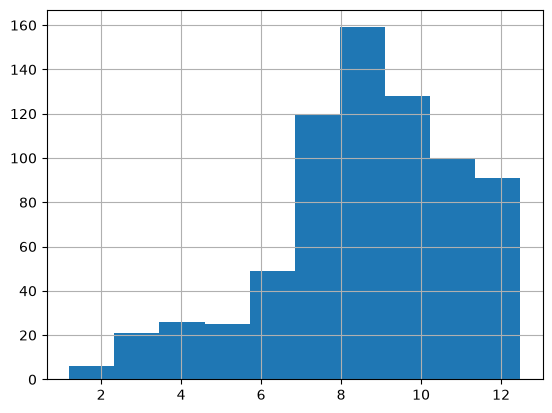

In [76]:
df.log10_parameters.hist()

Log10 data is more useful for analysis.  Even after taking log10, compute is still noticeably skewed left.

# EDA and Visualizations

## Training Compute & Parameters Overtime
Established the Fact:  AI training inputs such as compute and parameters have increased overtime

In [77]:
df.loc[df.publication_date.dt.year >= 1960].groupby(df.publication_date.dt.year)[["training_compute_flop", 
                                                                                  "log10_compute", "parameters", 
                                                                                  "log10_parameters"]].median()

,training_compute_flop,log10_compute,parameters,log10_parameters
publication_date,,,,
1960,"360,003,300.00",6.34,508.50,2.12
1962,"1,559,250.00",6.19,NaN,NaN
1963,"22,500,000.00",7.35,NaN,NaN
1965,"1,080,000.00",6.03,NaN,NaN
1966,"105,917,060.00",8.02,"2,061.00",3.31
1968,NaN,NaN,NaN,NaN
1969,NaN,NaN,"2,450.00",3.39
1973,NaN,NaN,357.00,2.55
1975,"5,184,000.00",6.71,"21,600.00",4.33


In [78]:
comp_1960 = df.loc[df.publication_date.dt.year == 1960, 'training_compute_flop'].median()
comp_2026 = df.loc[df.publication_date.dt.year == 2026, 'training_compute_flop'].median()
comp_change = (comp_2026 - comp_1960) / comp_1960 * 100
parm_1960 = df.loc[df.publication_date.dt.year == 1960, 'parameters'].median()
parm_2026 = df.loc[df.publication_date.dt.year == 2026, 'parameters'].median()
parm_change = (parm_2026 - parm_1960) / parm_1960 * 100

print(f"Compute increased from {comp_1960:,.0f} in 1960 to {comp_2026:,.0f} in 2026. An increase of {comp_change:,.0f}%")
print(f"Parameters increased from {parm_1960:,.0f} in 1960 to {parm_2026:,.0f} in 2026. An increase of {parm_change:,.0f}%")

Compute increased from 360,003,300 in 1960 to 4,319,999,999,999,999,798,673,408 in 2026. An increase of 1,199,989,000,100,832,256%
Parameters increased from 508 in 1960 to 688,000,000,000 in 2026. An increase of 135,299,901,572%


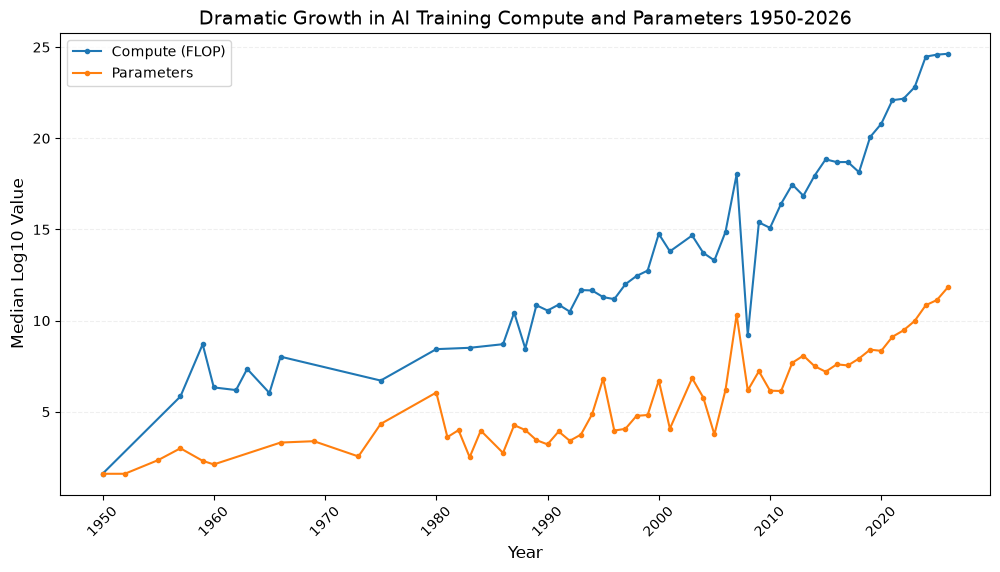

In [79]:
import matplotlib.pyplot as plt

# Calculate median compute and parameters by year
yr_data = (df.groupby(df.publication_date.dt.year)[["log10_compute", "log10_parameters"]].median().reset_index())

# Drop missing values separately so lines connect across available points
compute_data = yr_data.dropna(subset=["log10_compute"])
param_data = yr_data.dropna(subset=["log10_parameters"])

# Plot the line chart
plt.figure(figsize=(12, 6))

plt.plot(
    compute_data["publication_date"],     #call on the object with the dropped na
    compute_data["log10_compute"],
    marker="o", markersize=3,
    label="Compute (FLOP)"
)

plt.plot(
    param_data["publication_date"],
    param_data["log10_parameters"],
    marker="o", markersize=3,
    label="Parameters"
)

# Format the plot
plt.title("Dramatic Growth in AI Training Compute and Parameters 1950-2026", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Median Log10 Value", fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.2, linestyle='--')

# Show the plot
plt.show()

Note the graph is in log10 scale so it is not a 1-to-1 x-axis to y-axis.  Moving 1 unit to the right on x-axis equates to a 10x move up on the y-axis. Parameters increased from about 10^22 to 10^12 and compute rose even more from about 10^6 to 10^25.  See table above for visual of how big t

We have established the Fact:  AI training inputs such as compute and parameters have increased overtime.<br>
The question is whether the increase looks the same for all organizations, organization categories, countries, and domains.<br>

For this we will assess:
* Numeric values: log10_compute and log10_parameters
* Overtime: publication_date.dt.year
* By categories: org_simplified, org_cat_simplified, country_simplified, domain_simplified
  
For each set of categorical data, we will review:
* All Years: Number models, average compute & parameters, scatter plot with best fit over time
* Recent Years (2020-2026): scatter plot with best fit over time, reporting statistics, rate of change

## Create Functions
Define fuctions to be called for analysis by different Categories (and by year if warranted)

In [80]:
#Note: used AI help to arrange the course provided formulate for the log10 scatter plot to be called by changing the category and year

import matplotlib.pyplot as plt
import numpy as np

def plot_compute_parameters(data, group_col, start_year=None):    #I will use this graph multiple times so createing a function

    # Filter by year if requested, if not will bypass
    if start_year is not None:
        data = data[data.publication_date.dt.year >= start_year]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))                        #show together 2 graphs

    for g, d in data.groupby(group_col):

        # COMPUTE
        d_compute = d.dropna(subset=["publication_date", "log10_compute"])   #create subset with just the 2 columns & no nulls

        if len(d_compute) >= 2:
            years = d_compute.publication_date.dt.year
            compute = 10 ** d_compute.log10_compute

            axes[0].scatter(years, compute, s=6, label=g, alpha=0.4)          #graph actual observations, #dots were 'loud' so changed alpha & s

            slope, intercept = np.polyfit(years, d_compute.log10_compute, 1)
            line_years = np.linspace(years.min(), years.max(), 100)
            line_compute = 10 ** (slope * line_years + intercept)             #graph the line of best fit

            axes[0].plot(line_years, line_compute, alpha=0.8)

        # PARAMETERS
        d_param = d.dropna(subset=["publication_date", "log10_parameters"])      #follow same exact process as compute, but with parameters

        if len(d_param) >= 2:
            years = d_param.publication_date.dt.year
            parameters = 10 ** d_param.log10_parameters

            axes[1].scatter(years, parameters, s=6, label=g, alpha=0.4)         

            slope, intercept = np.polyfit(years, d_param.log10_parameters, 1)  #except put it at axes[1] to be the second graph
            line_years = np.linspace(years.min(), years.max(), 100)
            line_parameters = 10 ** (slope * line_years + intercept)

            axes[1].plot(line_years, line_parameters, alpha=0.8)

    axes[0].set_yscale("log")
    axes[1].set_yscale("log")

    axes[0].set_title(f"Training Compute by {group_col}")
    axes[1].set_title(f"Parameters by {group_col}")

    axes[0].set_ylabel("Training compute (FLOP)")
    axes[1].set_ylabel("Parameters")

    for ax in axes:
        ax.set_xlabel("Publication year")
        ax.legend()

    plt.tight_layout()
    plt.show()

In [81]:
def reporting_table(data, group_col, start_year=None):

    # Filter by year if requested, if not will bypass
    if start_year is not None:
        data = data[data.publication_date.dt.year >= start_year]

    # Create reporting indicators
    data = data.copy()                                                           #make a temp copy before adding reported columns
    data["compute_reported"] = data["log10_compute"].notna()                     #from calss example
    data["parameters_reported"] = data["log10_parameters"].notna()               #and repeated for parameters

    # Calculate reporting rates by group  Note: needed AI help for this part
    table = (
        data.groupby(group_col)[["compute_reported", "parameters_reported"]]        #use variable group_col so can call on different categories
        .mean()                                                                     
        .rename(columns={
            "compute_reported": "compute_reporting_rate",                          #make table name easier to ready
            "parameters_reported": "parameter_reporting_rate"
        })
        .round(2)
    )
    table.insert(0, "models", data.groupby(group_col).size())

    return table.sort_values("compute_reporting_rate", ascending=False).style.format({
            "models": "{:.0f}",                                                                   #puts #model in whole numbers
            "compute_reporting_rate": "{:.0%}",                                                   #puts rate in % format for easier to read
            "parameter_reporting_rate": "{:.0%}"
        })  

In [82]:
def growth_table(data, group_col, value_col="log10_compute", start_year=None):

    # Filter by year if requested
    if start_year is not None:
        data = data[data.publication_date.dt.year >= start_year]

    def calc_growth(d):

        # Drop rows missing date or the value being analyzed
        d = d.dropna(subset=["publication_date", value_col])

        # Need at least 2 observations 
        if len(d) < 2:
            return pd.Series({
                "models": len(d),
                "log10 per year": np.nan,
                "x per year": np.nan,
                "doubling (months)": np.nan
            })

        # Estimate slope of log10 value over time
        slope, _ = np.polyfit(
            d.publication_date.dt.year,
            d[value_col],
            1
        )

        return pd.Series({
            "models": len(d),
            "log10 per year": round(slope, 3),
            "x per year": round(10 ** slope, 2),
            "doubling (months)": (
                round(12 * np.log10(2) / slope, 1)
                if slope > 0 else np.nan
            )
        })

    return (
        data.groupby(group_col)
        .apply(calc_growth)
        .astype({"models": int})
        .sort_values("x per year", ascending=False)
    )

In [83]:
def plot_growth_side_by_side(data, group_col, start_year=None):

    compute = growth_table(                #keep the calculation from above code and turn it into a graph
        data, group_col,
        value_col="log10_compute",
        start_year=start_year
    )

    parameters = growth_table(
        data, group_col,
        value_col="log10_parameters",
        start_year=start_year
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    compute["x per year"].sort_values().plot.barh(    #specifically the x per year
        ax=axes[0],
        title="Training Compute Growth"
    )

    parameters["x per year"].sort_values().plot.barh(
        ax=axes[1],                                  # FIX: added ax= and comma
        title="Model Parameter Growth"
    )

    axes[1].set_ylabel("")                          #keep from repeating the label

    plt.tight_layout(w_pad=5)                       #put some space between the charts
    plt.show()

## Organization

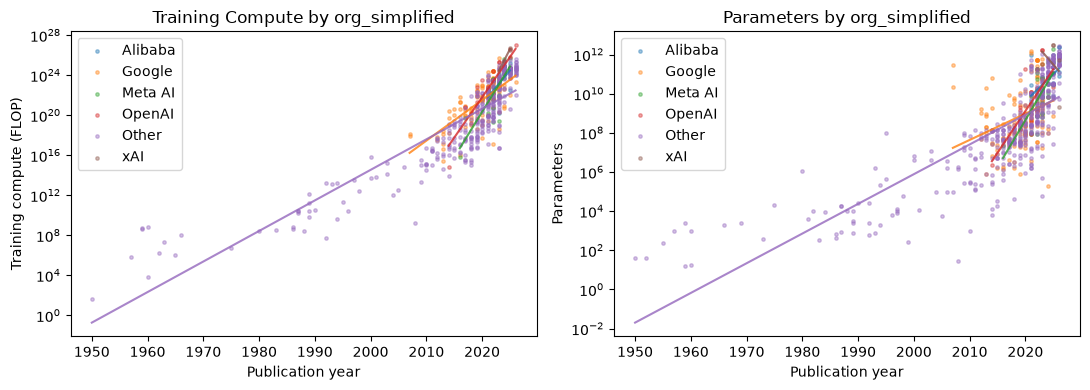

In [84]:
plot_compute_parameters(df, "org_simplified")

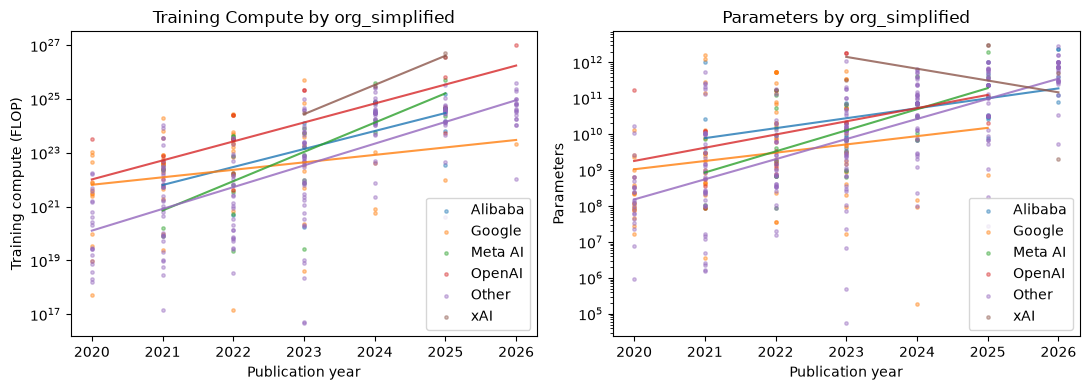

In [85]:
plot_compute_parameters(df, "org_simplified", 2020)

In both compute and parameters, Google had a bit of a lead in 2020 but since has not kept up and Meta has had the steepest growth.  For parameters, xAI had a jump in 2023 but has since matched all others.  The big names didn't hit the scene until after 2020 and while impressive increases the "other" category has kept up.  xAI and Open AI have maintained the lead on compute.  

In [86]:
reporting_table(df, "org_simplified", start_year=2020)

,models,compute_reporting_rate,parameter_reporting_rate
org_simplified,,,
Meta AI,42,67%,76%
Other,345,56%,75%
Google,124,52%,69%
Alibaba,37,51%,84%
xAI,9,44%,56%
OpenAI,71,24%,25%


xAI and especially Open AI have low reporting rates.  The reporting rates sheds doubt on the validity of the previously noted compute growth.

In [87]:
growth_table(df, "org_simplified",  value_col="log10_compute", start_year=2020)

,models,log10 per year,x per year,doubling (months)
org_simplified,,,,
Meta AI,28,1.09,12.25,3.30
xAI,4,1.09,12.19,3.30
Other,194,0.81,6.43,4.50
OpenAI,17,0.70,5.07,5.10
Alibaba,19,0.67,4.66,5.40
Google,65,0.28,1.89,13.00


In [88]:
growth_table(df, "org_simplified",  value_col="log10_parameters", start_year=2020)

,models,log10 per year,x per year,doubling (months)
org_simplified,,,,
Meta AI,32,0.59,3.86,6.20
Other,258,0.56,3.63,6.40
OpenAI,18,0.37,2.33,9.80
Alibaba,31,0.28,1.89,13.00
Google,85,0.23,1.70,15.70
xAI,5,-0.33,0.47,NaN


These tables confirm the previously noted observation of Meta AI haveing the steepest growth

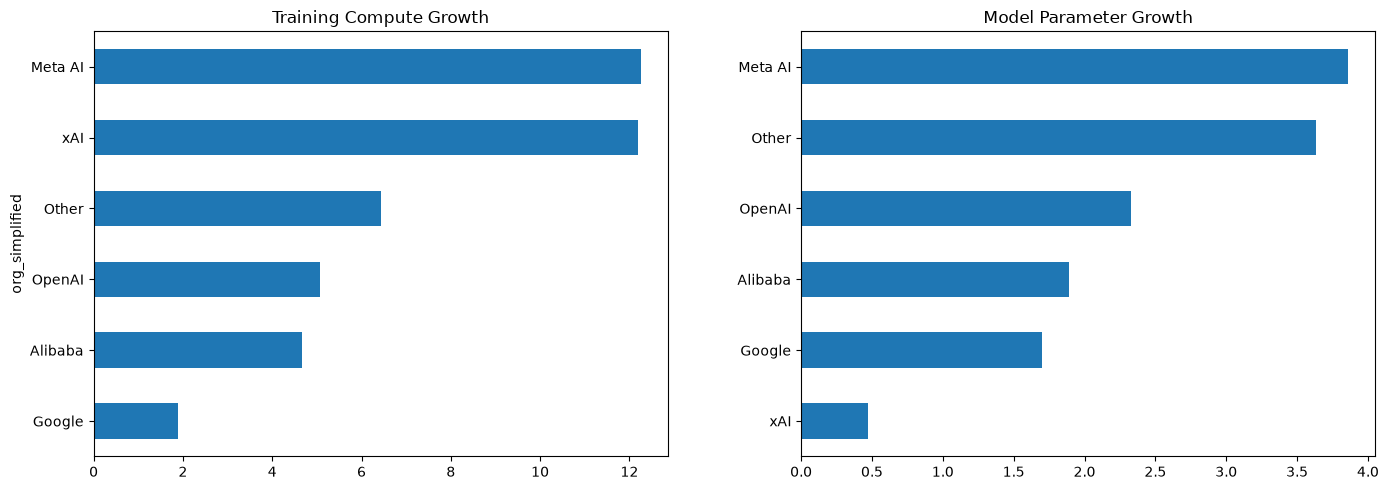

In [89]:
plot_growth_side_by_side(df, "org_simplified", start_year=2020)

## Organization Categorization

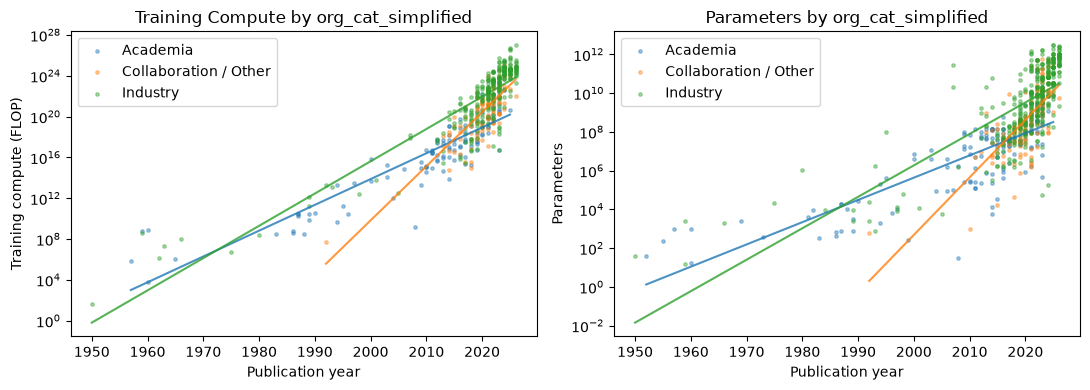

In [90]:
plot_compute_parameters(df, "org_cat_simplified")

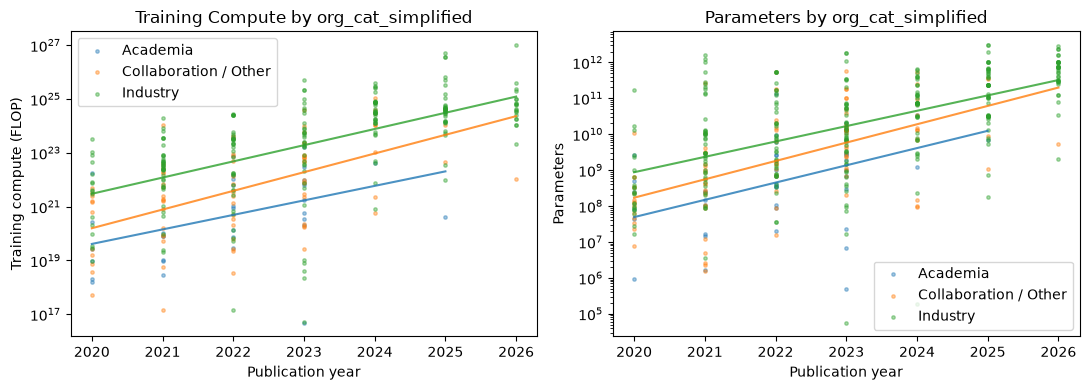

In [91]:
plot_compute_parameters(df, "org_cat_simplified", 2020)

There is not enough Government nor Research collective data to make any inference.  Also there is very little of difference between the categorizations.  Both Industry and Academia appear to follow the same slope with Industry retaining the highest amount of compute and parameters, followed by collaboration, and then Academia. 

In [92]:
reporting_table(df, "org_cat_simplified",  start_year=2020)

,models,compute_reporting_rate,parameter_reporting_rate
org_cat_simplified,,,
Collaboration / Other,117,68%,89%
Academia,58,59%,78%
Industry,451,47%,62%


Overall reporting for parameters is better than compute.  And Academia has a better reporting rate than Industry.  This could cast a little doubt on the previous observation of Industry retaining the higher compute and parameters

In [93]:
growth_table(df, "org_cat_simplified",  value_col="log10_compute", start_year=2020)

,models,log10 per year,x per year,doubling (months)
org_cat_simplified,,,,
Collaboration / Other,80,0.69,4.95,5.20
Industry,213,0.60,4.00,6.00
Academia,34,0.54,3.46,6.70


In [94]:
growth_table(df, "org_cat_simplified",  value_col="log10_parameters", start_year=2020)

,models,log10 per year,x per year,doubling (months)
org_cat_simplified,,,,
Collaboration / Other,104,0.51,3.24,7.10
Academia,45,0.48,3.02,7.50
Industry,279,0.43,2.68,8.40


Collaboration has the fastest rate of change, but not by much

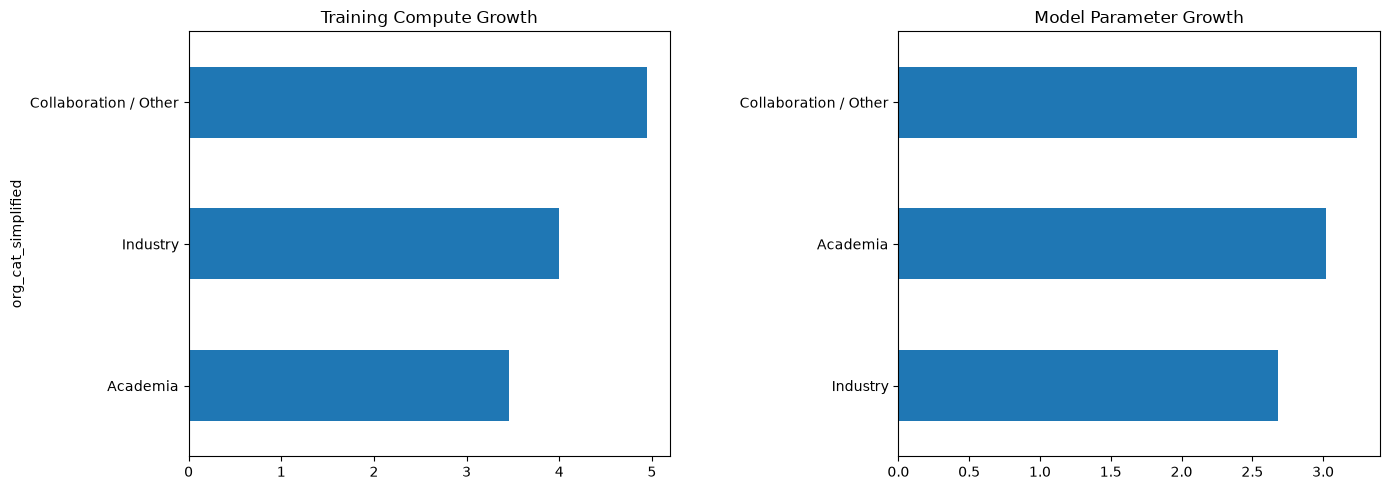

In [95]:
plot_growth_side_by_side(df, "org_cat_simplified", start_year=2020)

## Country of Organization

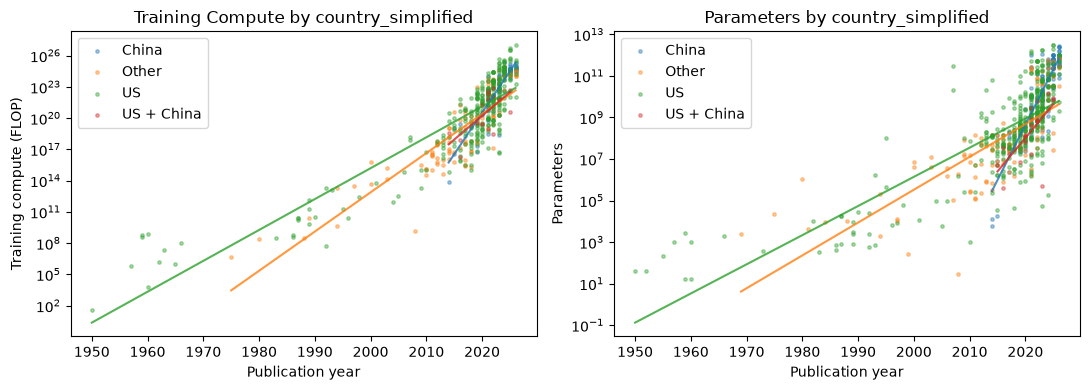

In [96]:
plot_compute_parameters(df, "country_simplified")

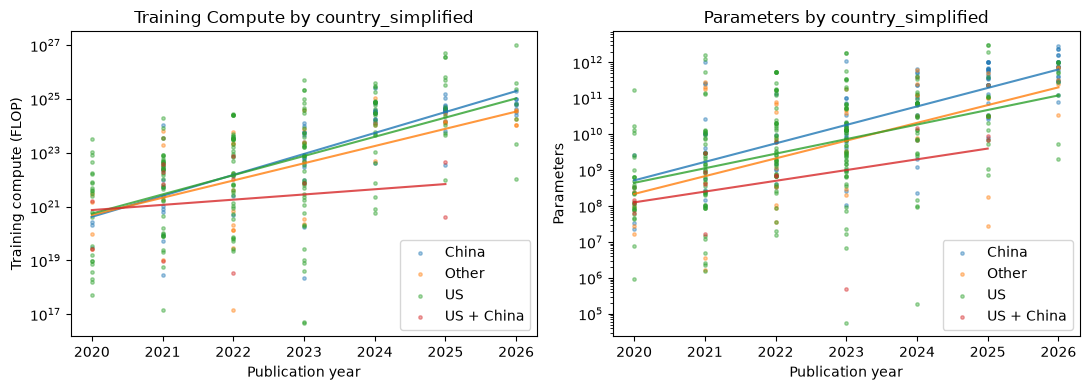

In [97]:
plot_compute_parameters(df, "country_simplified", 2020)

US and China appear neck-to-neck on compute with China having the highest number of parameters.  China + Other has a steep increase in compute, but is a relatively small sample size.  

In [98]:
reporting_table(df, "country_simplified", start_year=2020)

,models,compute_reporting_rate,parameter_reporting_rate
country_simplified,,,
US + China,18,67%,78%
Other,71,59%,76%
China,141,57%,83%
US,397,49%,61%


China has better reporting rate than the US, particularly in parameters.  Thus, it is possible the China gain in parameters is even higher than what is depicted on the graph

In [99]:
growth_table(df, "country_simplified",  value_col="log10_compute", start_year=2020)

,models,log10 per year,x per year,doubling (months)
country_simplified,,,,
China,80,0.78,6.01,4.60
US,193,0.71,5.17,5.10
Other,42,0.64,4.37,5.60
US + China,12,0.19,1.56,18.70


In [100]:
growth_table(df, "country_simplified",  value_col="log10_parameters", start_year=2020)

,models,log10 per year,x per year,doubling (months)
country_simplified,,,,
China,117,0.52,3.27,7.00
Other,54,0.49,3.12,7.30
US,244,0.41,2.55,8.90
US + China,14,0.30,1.99,12.10


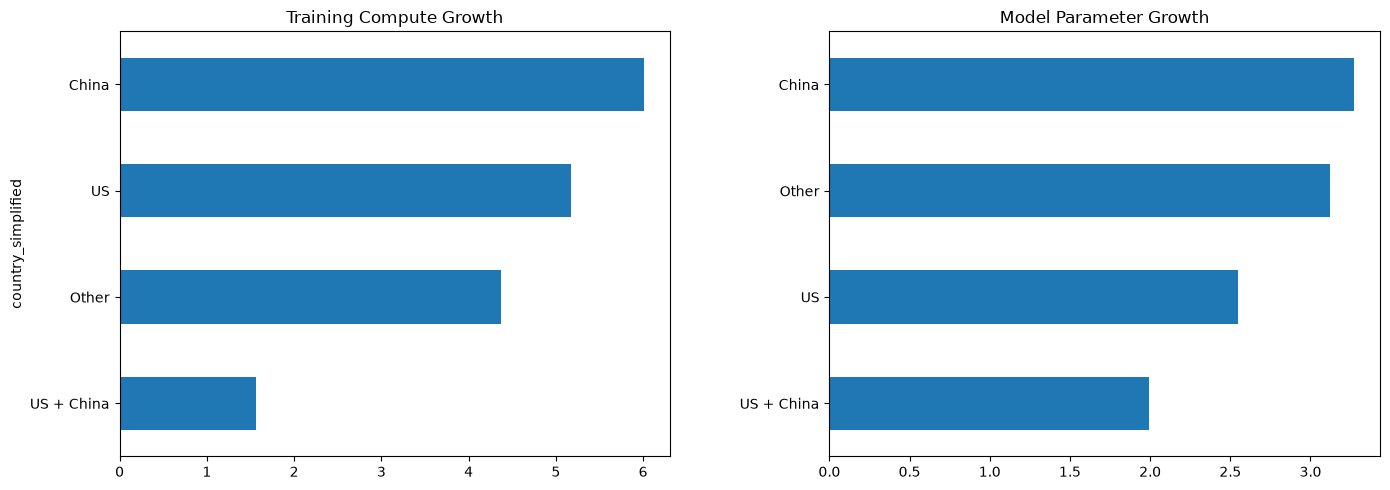

In [101]:
plot_growth_side_by_side(df, "country_simplified", start_year=2020)

For the China vs. US race, it would appear China is moving the fastest in both compute and parameters

In [102]:
#currious if may US is ahead on 'frontier' models. First let's see number of models in that category
df[df["frontier_model"] == True]["country_simplified"].value_counts()

country_simplified
US            86
Other         25
China          4
US + China     1
Name: count, dtype: int64

Since China has only 4 models, this is not worth looking at further

## Domain

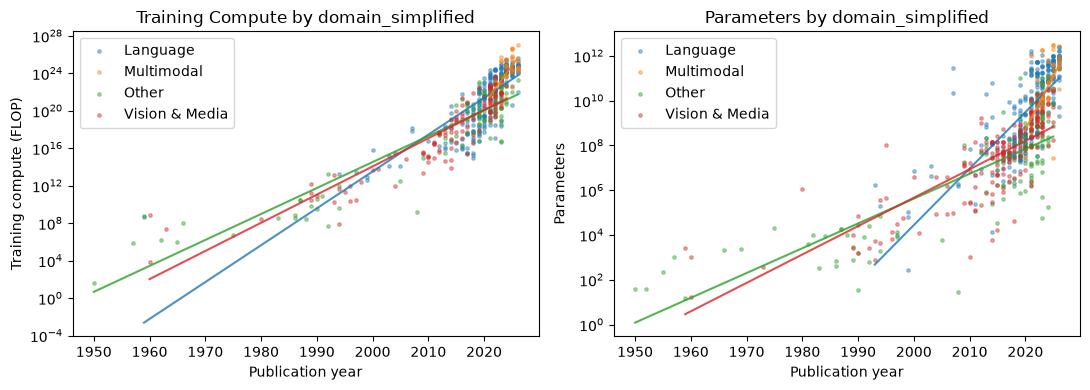

In [103]:
plot_compute_parameters(df, "domain_simplified")

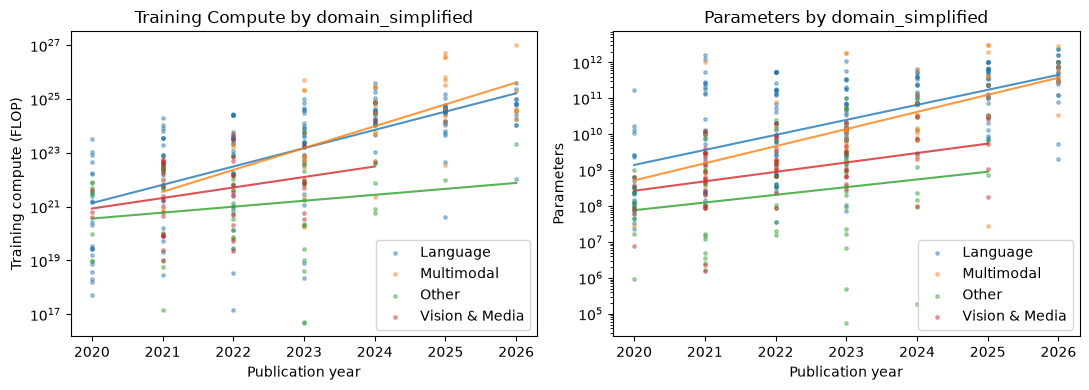

In [104]:
plot_compute_parameters(df, "domain_simplified", 2020)

Multimodal appears to be a fairly recent category, keeping relative pace with LLMs.  The two categories have the highest amount of compute and parameters.  Audio compute and parameters did not keep pace befor falling off as a category in 2023. 

In [105]:
reporting_table(df, "domain_simplified", start_year=2020)

,models,compute_reporting_rate,parameter_reporting_rate
domain_simplified,,,
Language,296,62%,81%
Other,97,56%,66%
Vision & Media,97,45%,64%
Multimodal,136,34%,46%


Given the relationship between Language and Multimodal, it is surprising to see Multimodal has a significantly lower reporting rate. 

In [106]:
growth_table(df, "domain_simplified",  value_col="log10_compute", start_year=2020)

,models,log10 per year,x per year,doubling (months)
domain_simplified,,,,
Multimodal,46,0.81,6.49,4.40
Language,183,0.68,4.79,5.30
Vision & Media,44,0.39,2.46,9.20
Other,54,0.22,1.66,16.40


In [107]:
growth_table(df, "domain_simplified",  value_col="log10_parameters", start_year=2020)

,models,log10 per year,x per year,doubling (months)
domain_simplified,,,,
Multimodal,62,0.48,3.00,7.60
Language,241,0.42,2.62,8.60
Vision & Media,62,0.26,1.83,13.80
Other,64,0.21,1.64,16.90


Multimodal had the fastest rate of increase, but is also the newest category

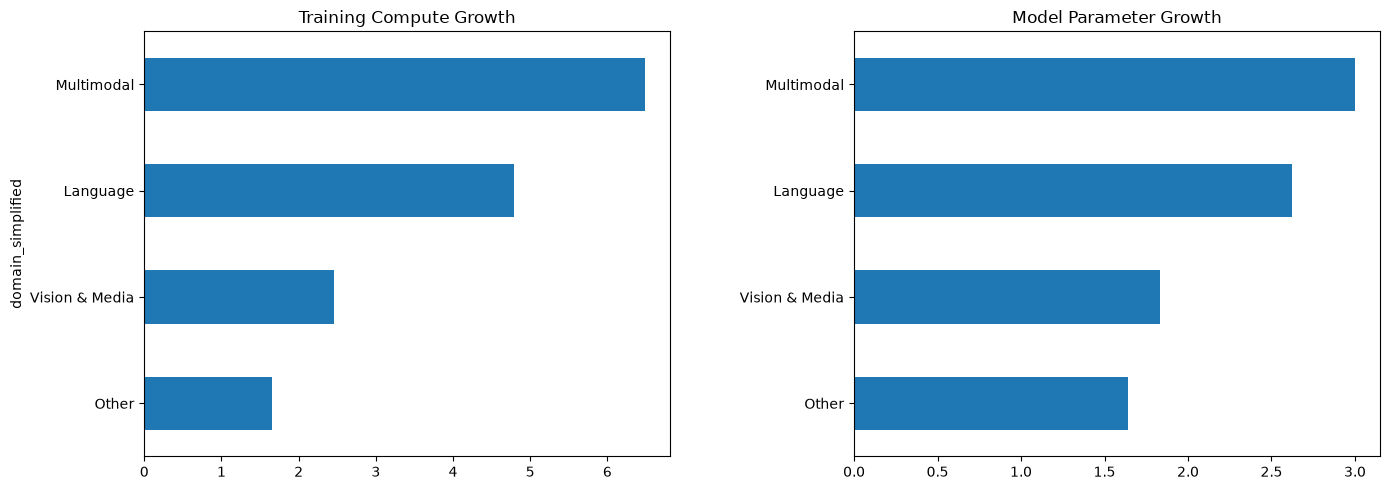

In [108]:
plot_growth_side_by_side(df, "domain_simplified", start_year=2020)

# Key Insights / Conclusions

Top 3 Insights

1. China vs. US:  I expected US to have the highest amount of compute and parameters in their training data; however, since 2021 China has been on top in both and with a faster rate of change.  Since 2020 China has increased compute 6.01 times per year and parameters 3.27 times per year compared to US which has increased compute 5.17 times per year and parameters 2.55 times per year. Also China has better reporting statistics, reporting compute for 57% and parameters for 83% of their 141 notable models since 2020.  Whereas US has reported compute for 49% and parameters for 61% of their 397 notable models since 2020.  If the US chose to report statistics for the higher metrics, then China may be even further ahead than the numbers show.

2. Meta AI vs. Open AI: Since 2010, Meta AI has been middle-to-lower end of the pack in terms of amount of training compute and parameters, but what is interesting is the rate of increase.  They have increased amount of compute 12.25 times per year and parameters 3.86 times per year.  Further, they have the highest reporting rates for both, reporting compute for 67% and parameters for 76% of their 42 notable models.  In contrast, Open AI has only reported compute for 24% and parameters for 25% of their 71 notable models.  So, while it appears Open AI has some of the highest training compute and parameters, their low reporting numbers shed some doubt on the reliability of that statistic.  Lastly, xAI has reported some of the highest levels of compute and parameters, but they only have 9 notable models and reported compute and parameters for just 4 and 5 of their models respectively.  Thus, I would not put much stock in their data at this time.

3. Industry vs. Academia:  While the rate of change is fairly consistent, Industry has retained higher levels of compute and parameters for nearly 50 years. Although, at least since 2020, Academia has better reporting statistics. So while somewhat interesting this finding isn't shocking.  

# Limitations & Next Steps

Limitations:  The biggest limitation was incomplete reporting.  The information was provided by the organizations and, as we saw, many chose not to report all of their data. Another limitaiton was the selection of notable models.  It would be interesting to look at just the frontier models but since China only had 4 it was not worth reviewing.  Lastly, I lost a little fidelity in combining categories.  For example I put all US + other countries as the US category.  I did this to reduce the number of different categories that would otherwise clutter the charts. I also did this since some categories alone didn't have enough models to consider separately (i.e. very few "government" models)